# MCMC analysis of FRB constraints on cosmological parameters and cosmic baryons

**Note**: This notebook uses the updated formalism developed for Zhuge+ (2025) [here].

## Run properties and loading modules

In [1]:
### If the MCMC functions need to be imported from a file, this should be OFF
## Depends on how the OS handles multiprossecing
RUN_IN_NOTEBOOK = False

SAVE_DATA = False
SAVE_FIG = False

In [2]:
import sys
sys.path.append('../../Python_scripts')
sys.path.append('../interpolation')

### Import packages
from config import *
from support import *
from cosmo_support import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
### MCMCM packages

if RUN_IN_NOTEBOOK:
    import emcee
    from multiprocessing import Pool
else:
    from mcmc_support_Svar import *

## Upload data

- Full data of 117 FRBs
- Macquart et al FRBs

In [4]:
data_all=pd.read_csv('../../Data/FRB_data/FRB_new.csv')
# data_Macq=pd.read_csv('../../Data/FRB_data/FRB_Macquart.csv')

In [5]:
# data_all, data_Macq

**Filtering** some FRBs:

We perform two cuts in the FRBs analysis:

- Remove two FRBs that have very large DMs for their redshift
- We perform a redshift cut (for small redshifts), since these are creating an issue with the variance calculation

In [6]:
z_cut = 0.2

print(f"Original FRB sample has: {len(data_all)} FRBs.")
data_all = data_all[data_all['FRB'] != 'FRB 20190520B']
data_all = data_all[data_all['FRB'] != 'FRB 20220831A']
data_all_03 = data_all[data_all['z'] >= z_cut]
print(f"Final FRB sample has: {len(data_all_03)} FRBs.")
# data03.head()

Original FRB sample has: 117 FRBs.
Final FRB sample has: 55 FRBs.


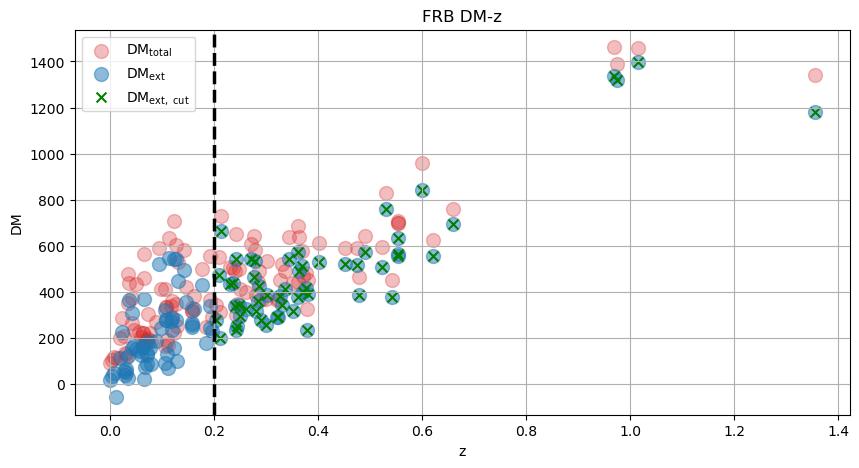

In [7]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(111)

ax1.scatter(data_all['z'], data_all['DM'], s=100, marker='o', label=r'DM$_{\rm total}$', alpha=0.3, c='tab:red')
ax1.scatter(data_all['z'], data_all['DM_ext(ne2001)'], s=100, marker='o', label=r'DM$_{\rm ext}$', alpha=0.5)
ax1.scatter(data_all_03['z'], data_all_03['DM_ext(ne2001)'], s=50, marker='x', label=r'DM$_{\rm ext,\ cut}$', c='green')

ax1.axvline(x=z_cut, ls='--', lw=2.5, c='black')
ax1.set_xlabel(r'z')
ax1.set_ylabel(r'DM')
ax1.set_title('FRB DM-z')
ax1.grid(True)
ax1.legend(loc='upper left')

plt.show()

# Preparation interpolation

In [8]:
if RUN_IN_NOTEBOOK:

    load_arrays=np.load('./interpolation/095_C0mean.npz')
    Sigmas=load_arrays['a']
    Errors=load_arrays['d']
    C0s=load_arrays['c']
    As=load_arrays['b']
    
    sigma_error_inter= interpolate.interp1d(Errors, Sigmas, kind=1,bounds_error=False, 
        # fill_value='extrapolate'
        )    
    
    ## Interpolation of C0 terms (see Macquart+ paper)
    C0_sigma_inter = interpolate.interp1d(Sigmas, C0s, kind=1,bounds_error=False, 
        # fill_value='extrapolate'
        )

    ## Interpolation of normalisation factor (so that pdf is normalised to 1)
    A_sigma_inter = interpolate.interp1d(Sigmas, As, kind=1,bounds_error=False, 
        # fill_value='extrapolate'
        )

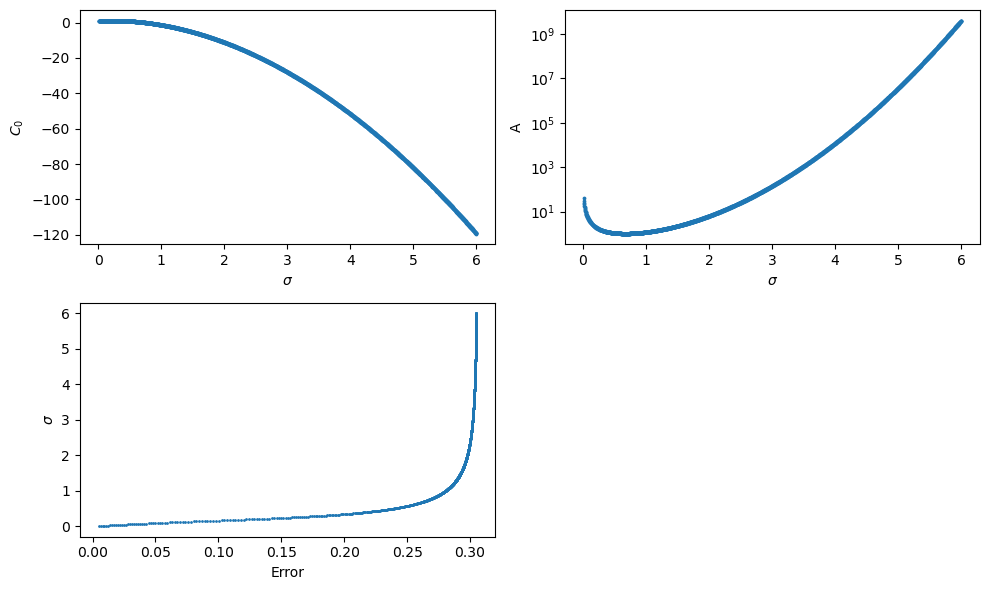

In [9]:
fig = plt.figure(figsize=(10, 6))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax1.scatter(Sigmas, C0s,  s=3)
ax1.set_ylabel(r'$C_0$')
ax1.set_xlabel(r'$\sigma$')

ax2.scatter(Sigmas, As,  s=3)
ax2.set_ylabel('A')
ax2.set_xlabel(r'$\sigma$')
ax2.set_yscale('log')

ax3.scatter(Errors, Sigmas,s=1)
ax3.set_ylabel(r'$\sigma$')
ax3.set_xlabel(r'Error')

plt.tight_layout()
plt.show()

In [10]:
z=0.2
print(np.sqrt(0.017/z))

0.29154759474226505


# MCMC

Constrain $H_0 \Omega_0 f_{IGM}=const $

In [ ]:
if RUN_IN_NOTEBOOK:
    
    def sigma_error(error):
        return error
    
    
    def log_likelihood(theta, data):
        """
        Calculate the log likelihood for a set of parameters given the data.

        Args:
            theta: Array of parameters [F, HOf, sigma_host, e_mu]
            data: Pandas DataFrame containing FRB data

        Returns:
            Log likelihood
        """
        S, HOf, sigma_host, e_mu = theta

        log_like = 0.0

        try:
            for _, row in data.iterrows():
                prob = calculate_dm_probability_num_HOf_fast(
                    DM_frb_max=row['DM_ext(ne2001)'],
                    z=row['z'],
                    S=S,
                    HOf=HOf,
                    sigma_host=sigma_host,
                    e_mu=e_mu,
                    f_sigma_error=sigma_error_inter,f_C0_sigma=C0_sigma_inter,f_A_sigma=A_sigma_inter
                )

                if prob > 0:
                    log_like += np.log(prob)
                else:
                    return -np.inf

            return log_like
        except Exception as e:
            print(f"Error in log_likelihood: {e} with parameters {theta}")
            return -np.inf
        
        
    def log_prior(theta):
        """
        Calculate the log of the prior probability for a set of parameters.

        Args:
            theta: Array of parameters [F, HOf, sigma_host, e_mu]

        Returns:
            Log prior probability
        """
        S, HOf, sigma_host, e_mu = theta

        # Define your prior ranges here
        S_min, S_max = 0.01, 0.025 #0.2 # Example range, adjust based on your model
        HOf_min, HOf_max = 1.0, 5.0  # Example range, adjust based on your model
        sigma_host_min, sigma_host_max = 0.2,1.4  # Example range
        e_mu_min, e_mu_max = 10, 250  # Example range # e_mu_min, e_mu_max = 50, 300  # Example range

        # Check if parameters are within prior ranges
        if (S_min <= S <= S_max and 
            HOf_min <= HOf <= HOf_max and 
            sigma_host_min <= sigma_host <= sigma_host_max and 
            e_mu_min <= e_mu <= e_mu_max):
            return 0.0  # Log(1) = 0, flat prior
        else:
            return -np.inf  # Log(0) = -inf, outside prior range       

    def log_probability(theta, data):
        """
        Calculate the log probability (posterior) for a set of parameters.

        Args:
            theta: Array of parameters [F, HOf, sigma_host, e_mu]
            data: Pandas DataFrame containing FRB data

        Returns:
            Log posterior probability
        """
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf

        ll = log_likelihood(theta, data)
        if not np.isfinite(ll):
            return -np.inf

        return lp + ll

    def run_mcmc(data, initial_params, nwalkers=32, heating=10, nsteps=10000):
        """
        Run the MCMC analysis.

        Args:
            data: Pandas DataFrame containing FRB data
            initial_params: Initial parameter values [F, HOf, sigma_host, e_mu]
            nwalkers: Number of walkers
            nsteps: Number of steps per walker
            ndim: Number of dimensions (parameters)

        Returns:
            sampler: emcee sampler object with results
        """

        ndim=len(initial_params)

        # Set initial positions with small random offsets
        pos = initial_params + 0.05 * np.random.randn(nwalkers, ndim)
        # pos = [initial_params + _*1e-2 * np.random.randn(ndim) for _ in range(nwalkers)]

        for i in range(nwalkers):
            while log_prior(pos[i]) == -np.inf:
                pos[i] = initial_params + 0.05 * np.random.randn(ndim)

        # Set up the sampler
        with Pool() as pool:
            sampler = emcee.EnsembleSampler(
                nwalkers, ndim, log_probability, 
                args=(data,), pool=pool,
                moves=[(emcee.moves.DEMove(), 0.8),
                       (emcee.moves.DESnookerMove(), 0.2)]
            )

            # Run the MCMC
            print("Running MCMC...")

            print("heating...")
            state = None
            with tqdm(total=heating) as pbar:
                for i, result in enumerate(sampler.sample(pos, iterations=heating)):
                    pbar.update(1)
                    state = result
                    if i % 100 == 0:
                        # Calculate acceptance fraction periodically
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")

            print("main running...")
            with tqdm(total=nsteps) as pbar:
                for i, result in enumerate(sampler.sample(state.coords, iterations=nsteps)):
                    pbar.update(1)

                    # check acceptance fraction
                    if i % 100 == 0:
                        acc_frac = np.mean(sampler.acceptance_fraction)
                        pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")

                        # if acceptance fraction always = 0，reset initial parameters
                        if i > 500 and acc_frac < 0.001:
                            print("warning: acceptance fraction too low，reset parameters or resun MCMC")

        # check acceptance fraction
        final_acc_frac = np.mean(sampler.acceptance_fraction)
        print(f"final acceptance fraction: {final_acc_frac:.3f}")

        if final_acc_frac < 0.01:
            print("warning: acceptance fraction too low，reset parameters or resun MCMC")

        return sampler

**MCMC Run properties**

In [ ]:
N_WALKERS = 8
HEATING = 500
N_STEPS = 30000
LOAD_DATA = False

## Initial parameters for chains (adjust based on your model)
S_0 = 0.015
HOF_0 = 3.0
SIGMA_HOST_0 = 0.8
E_MU_0 = 150

1. Run with all FRB data

In [13]:
if LOAD_DATA:
    samples03=np.load('./posterior/mcmc_all_z03.npy')

else:
    # Main execution
    if __name__ == "__main__":

        # Define initial parameters: [F, HOf, sigma_host, e_mu]
        initial_params = np.array([S_0, HOF_0, SIGMA_HOST_0, E_MU_0])

        # Run MCMC
        sampler03 = run_mcmc(data_all_03, initial_params, nwalkers=N_WALKERS, heating=HEATING, nsteps=N_STEPS)

Running MCMC...
heating...


  0%|          | 0/500 [00:00<?, ?it/s]/home/zhuge/miniconda3/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
Acceptance fraction: 0.198: 100%|██████████| 500/500 [00:16<00:00, 30.60it/s]


main running...


Acceptance fraction: 0.213: 100%|██████████| 30000/30000 [17:10<00:00, 29.12it/s]

final acceptance fraction: 0.213


In [20]:
if not LOAD_DATA:
    # Analyze results
    samples03, params_median03, params_errors03 = mcmc_analyze_results(sampler03)

    # Print results
    param_names = ['S', 'HOf', 'sigma_host', 'e_mu']
    print("MCMC Results:")
    for i, name in enumerate(param_names):
        print(f"{name} = {params_median03[i]:.3f} ± {params_errors03[i]:.3f}")

    # Plot results
    # plot_results(samples, param_names)

    # Save samples to file for later analysis if needed
    if SAVE_DATA:
        np.save('./posterior/mcmc_all_z03.npy', samples03)

    print("\nMCMC analysis complete!")

else:
    print("Using loaded posteriors for analysis!")

MCMC Results:
S = 0.017 ± 0.004
HOf = 2.517 ± 0.208
sigma_host = 0.633 ± 0.155
e_mu = 151.902 ± 38.977

MCMC analysis complete!


In [23]:
ObH2=0.0224*100*100
f=0.84
HOf=2.517
print(ObH2/(HOf/f))

74.75566150178783


**Analysing MCMC results**

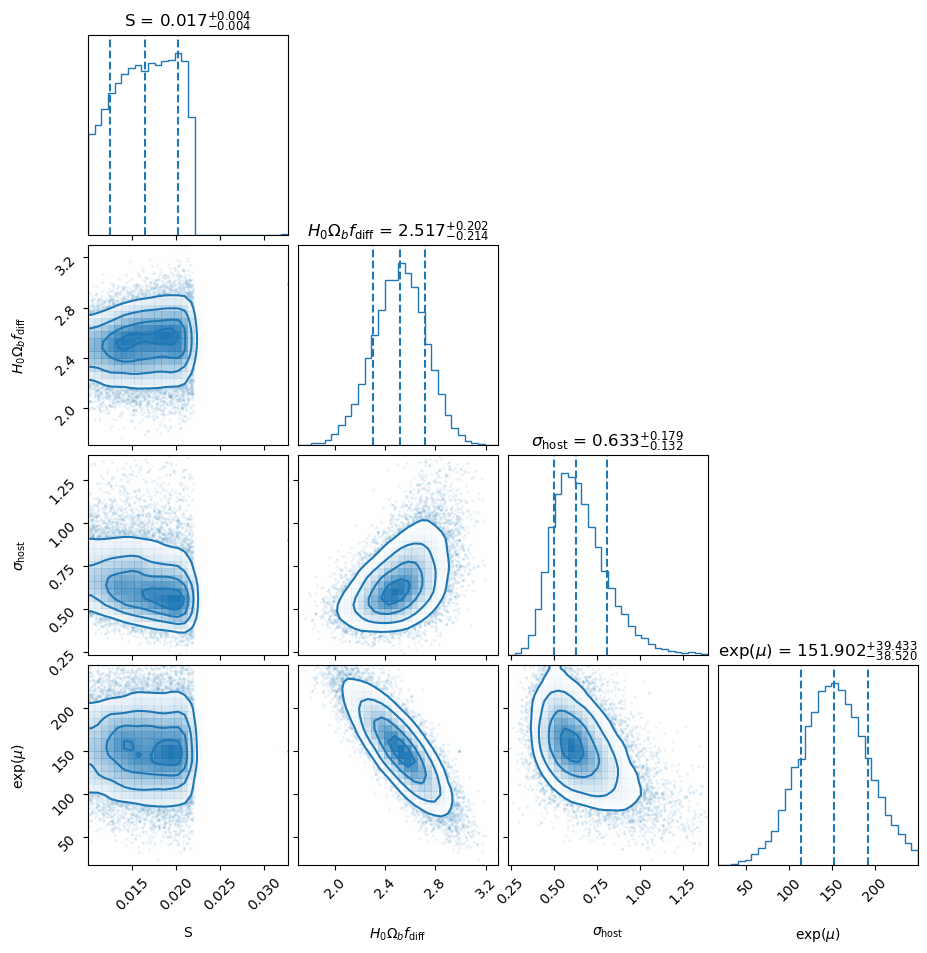

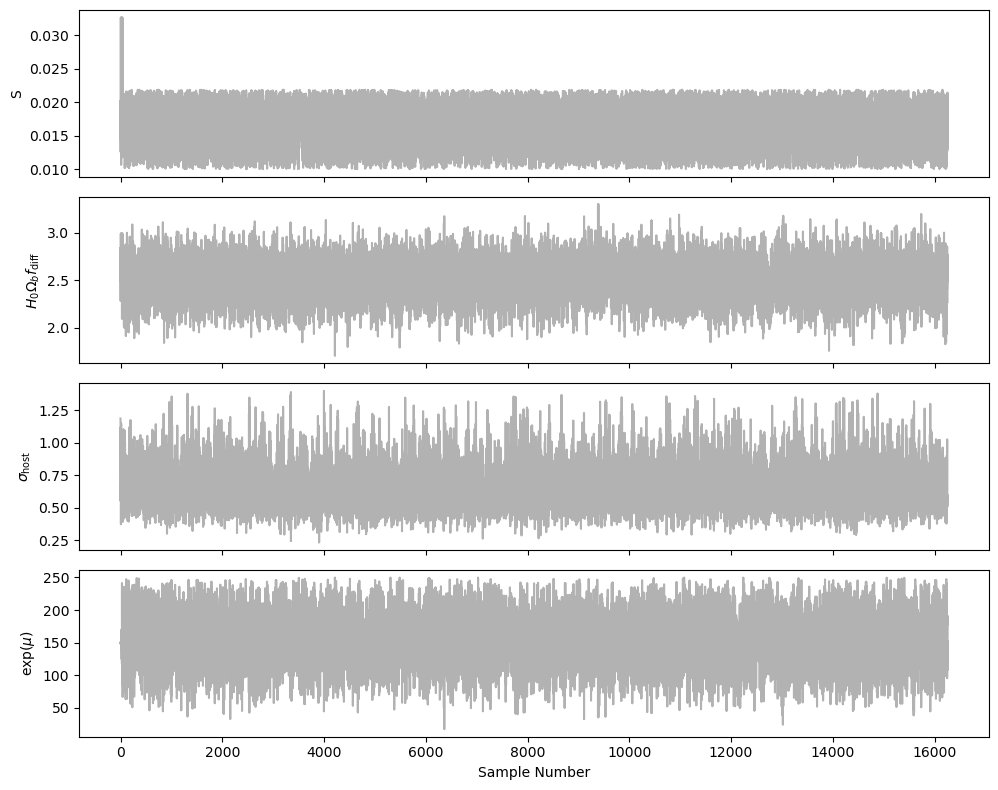

In [22]:
param_names = ['S', r'$H_0 \Omega_b f_{\rm diff}$', r'$\sigma_{\rm host}$', r'$\exp(\mu)$']

if SAVE_FIG:
    fig_name = './plot/MCMC_all_z03'
else:
    fig_name=None
    
mcmc_plot_results(samples03, param_names, savetitle=fig_name)

-----------------------------------------------------------------------------

# UNDER CONSTRUCTION (BELOW)

Constrain $H_0 \Omega_0 f_{IGM}=H_0 \Omega_0 f_{IGM,0}(1+a
\cdot z)$

In [48]:
def DM_IGM_H0_O_b_f_IGM_linear_fast(z, H0_O_b_f_IGM, a, Om=OMEGA_MATTER, w=-1):
    
    def integrand(z):
        return (1+a*z)*(1+z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))
        # return (1+z+a*z)/np.sqrt(Om*(1+z)**3+(1-Om)*(1+z)**(3*(1+w)))

    factor = 3*C_LIGHT*H0_O_b_f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    
    zs=np.linspace(0, z, 5000)
    dms=integrand(zs)
    integral=np.trapz(dms, x=zs)
    
    unit_transform = DM_2_PCCM3*KM_2_MPC
    
    DM = unit_transform*factor*integral
    
    return DM

In [49]:
def calculate_dm_probability_num_HOf_linear_fast(DM_frb_max, z, S, HOf, a, e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_linear_fast(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0, DM_frb_max / DM_th, 5000)
    
    sigma=sigma_error_inter(np.sqrt(f_variance_delta(S,z)))
    
    C_0=C0_sigma_inter(sigma)
    A = A_sigma_inter(sigma)
    
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [31]:
def calculate_dm_probability_num_HOf_linear_v2(DM_frb_max, z, S, HOf, a ,e_mu, sigma_host):
    
    ## Cosmic calculation    
    DM_th = DM_IGM_H0_O_b_f_IGM_linear(z=z, H0_O_b_f_IGM=HOf, a=a, Om=OMEGA_MATTER, w=-1)
    
    Delta_array = np.linspace(0.01, DM_frb_max / DM_th-0.01, 5000)
    
    sigma=sigma_var(np.sqrt(f_variance_delta(S,z)))
    
    C_0=find_C0_sigma(sigma=sigma, sigmas=sigmas, C0s=C0s)
    A = find_A_sigma(C_0=C_0, sigma=sigma, alpha=3, beta=3)
    pdf_cosmic = pdf_DM_cosmo(Delta_array, C_0, A=A, sigma=sigma)
    
    ## Host calculation
    pdf_host = pdf_DM_host((1+z)*(DM_frb_max-DM_th * Delta_array), e_mu, sigma_host)
    
    ## Combine together    
    prob = np.trapz(pdf_host*pdf_cosmic, x=Delta_array)
    
    ## Transform to probabilities
    # dDM = np.abs(np.diff(DM_frb_array)[0])/DM_IGM_O_bh_70(z=z, O_bh_70=O_bh_70, Om=OMEGA_MATTER, w=-1,alpha=0)/(1+z)
    
    return prob*(1+z)

In [36]:
# def log_probability(theta, data):
#     """
#     Calculate the log probability (posterior) for a set of parameters.
    
#     Args:
#         theta: Array of parameters [F, HOf, sigma_host, e_mu]
#         data: Pandas DataFrame containing FRB data
    
#     Returns:
#         Log posterior probability
#     """
#     lp = log_prior(theta)
#     if not np.isfinite(lp):
#         return -np.inf
    
#     ll = log_likelihood(theta, data)
#     if not np.isfinite(ll):
#         return -np.inf
    
#     return lp + ll

# def run_mcmc(data, initial_params, nwalkers=32, heating=100, nsteps=10000):
#     """
#     Run the MCMC analysis.
    
#     Args:
#         data: Pandas DataFrame containing FRB data
#         initial_params: Initial parameter values [F, HOf, sigma_host, e_mu]
#         nwalkers: Number of walkers
#         nsteps: Number of steps per walker
#         ndim: Number of dimensions (parameters)
    
#     Returns:
#         sampler: emcee sampler object with results
#     """
#     ndim=len(initial_params)
#     # Set initial positions with small random offsets
#     pos = initial_params + 0.1 * np.random.randn(nwalkers, ndim)
#     # pos = [initial_params + _*1e-2 * np.random.randn(ndim) for _ in range(nwalkers)]
    
#     for i in range(nwalkers):
#         while log_prior(pos[i]) == -np.inf:
#             pos[i] = initial_params + 0.1 * np.random.randn(ndim)
    
#     # Set up the sampler
#     with Pool() as pool:
#         sampler = emcee.EnsembleSampler(
#             nwalkers, ndim, log_probability, 
#             args=(data,), pool=pool,
#             moves=[(emcee.moves.DEMove(), 0.8),
#                    (emcee.moves.DESnookerMove(), 0.2)]
#         )
        
#         # Run the MCMC
#         print("Running MCMC...")
        
#         print("heating...")
#         state = None
#         with tqdm(total=heating) as pbar:
#             for i, result in enumerate(sampler.sample(pos, iterations=heating)):
#                 pbar.update(1)
#                 state = result
#                 if i % 100 == 0:
#                     # Calculate acceptance fraction periodically
#                     acc_frac = np.mean(sampler.acceptance_fraction)
#                     pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
    
#         print("main running...")
#         with tqdm(total=nsteps) as pbar:
#             for i, result in enumerate(sampler.sample(state.coords, iterations=nsteps)):
#                 pbar.update(1)
                
#                 # check acceptance fraction
#                 if i % 100 == 0:
#                     acc_frac = np.mean(sampler.acceptance_fraction)
#                     pbar.set_description(f"Acceptance fraction: {acc_frac:.3f}")
                    
#                     # if acceptance fraction always = 0，reset initial parameters
#                     if i > 500 and acc_frac < 0.001:
#                         print("warning: acceptance fraction too low，reset parameters or resun MCMC")
    
#     # check acceptance fraction
#     final_acc_frac = np.mean(sampler.acceptance_fraction)
#     print(f"final acceptance fraction: {final_acc_frac:.3f}")
    
#     if final_acc_frac < 0.01:
#         print("warning: acceptance fraction too low，reset parameters or resun MCMC")
    
#     return sampler

# def analyze_results(sampler, burn_in=100, thin=15):
#     """
#     Analyze the MCMC results.
    
#     Args:
#         sampler: emcee sampler with results
#         burn_in: Number of initial steps to discard
#         thin: Thinning factor for samples
    
#     Returns:
#         samples: Flattened, burned-in, and thinned samples
#         params_median: Median parameter values
#         params_errors: Parameter uncertainties (16th and 84th percentiles)
#     """
#     # Discard burn-in, flatten and thin the samples
#     flat_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
    
#     # Calculate the median and 16th and 84th percentiles for the parameters
#     params_median = np.median(flat_samples, axis=0)
#     params_lower = np.percentile(flat_samples, 16, axis=0)
#     params_upper = np.percentile(flat_samples, 84, axis=0)
    
#     # Calculate errors
#     params_errors = [(params_upper[i] - params_lower[i]) / 2 for i in range(len(params_median))]
    
#     return flat_samples, params_median, params_errors

# def plot_results(samples, param_names=['F', 'HOf', 'a', 'sigma_host', 'e_mu'],bin=30):
#     """
#     Plot the MCMC results.
    
#     Args:
#         samples: MCMC samples
#         param_names: Names of the parameters
#     """
#     import corner
    
#     # Create corner plot
#     fig = corner.corner(
#         samples, 
#         labels=param_names,
#         quantiles=[0.16, 0.5, 0.84],
#         show_titles=True,
#         title_kwargs={"fontsize": 12},
#         title_fmt='.3f',
#         bins=bin
#     )
    
#     # plt.savefig("mcmc_corner_plot.png", dpi=300, bbox_inches='tight')
#     plt.show()
#     plt.close()
    
#     # Plot chains for each parameter
#     fig, axes = plt.subplots(5, 1, figsize=(10, 8), sharex=True)
    
#     for i, (ax, name) in enumerate(zip(axes, param_names)):
#         ax.plot(samples[:, i], 'k-', alpha=0.3)
#         ax.set_ylabel(name)
#         if i == 3:
#             ax.set_xlabel("Sample Number")
    
#     plt.tight_layout()
#     plt.show()
#     # plt.savefig("mcmc_chains.png", dpi=300)
#     plt.close()

In [ ]:
def log_prior(theta):
    """
    Calculate the log of the prior probability for a set of parameters.
    
    Args:
        theta: Array of parameters [F, HOf, a, sigma_host, e_mu]
    
    Returns:
        Log prior probability
    """
    # S, HOf, a, sigma_host, e_mu = theta
    S, a, sigma_host, e_mu = theta
    
    # Define your prior ranges here
    S_min, S_max = 0.01, 0.04
    # HOf_min, HOf_max = 1.0, 5.0
    a_min, a_max = -1.0, 1.0
    sigma_host_min, sigma_host_max = 0.2,1.4
    e_mu_min, e_mu_max = 10, 250
    
    # Check if parameters are within prior ranges
    if (S_min <= S <= S_max and 
        # HOf_min <= HOf <= HOf_max and 
        a_min <= a <= a_max and
        sigma_host_min <= sigma_host <= sigma_host_max and 
        e_mu_min <= e_mu <= e_mu_max):
        return 0.0  # Log(1) = 0, flat prior
    else:
        return -np.inf  # Log(0) = -inf, outside prior range

def log_likelihood(theta, data):
    """
    Calculate the log likelihood for a set of parameters given the data.
    
    Args:
        theta: Array of parameters [F, HOf, sigma_host, e_mu]
        data: Pandas DataFrame containing FRB data
    
    Returns:
        Log likelihood
    """
    # S, HOf, a, sigma_host, e_mu = theta
    S, a, sigma_host, e_mu = theta
    
    log_like = 0.0
    
    try:
        for _, row in data.iterrows():
            prob = calculate_dm_probability_num_HOf_linear_fast(
                DM_frb_max=row['DM_ext'],
                z=row['z'],
                S=S,
                HOf=2.7832, #2.774,
                a=a,
                sigma_host=sigma_host,
                e_mu=e_mu
            )
            
            if prob > 0:
                log_like += np.log(prob)
            else:
                return -np.inf
        
        return log_like
    except Exception as e:
        print(f"Error in log_likelihood: {e} with parameters {theta}")
        return -np.inf

In [38]:
# data = data[data['z'] <= 0.8]

In [56]:
# Main execution
if __name__ == "__main__":
    # Load your data
    # data = pd.read_csv('your_frb_data.csv')  # Replace with your data file
    
    # Define initial parameters: [S, HOf, a, sigma_host, e_mu]
    initial_params_a = np.array([0.02, 0.1, 0.8, 150])  # Adjust based on your model
    
    # Run MCMC
    sampler_a = run_mcmc(data, initial_params_a, nwalkers=32, heating=100, nsteps=10000)
    
    # Analyze results
    samples_a, params_median_a, params_errors_a = mcmc_analyze_results(sampler_a)
    
    # Print results
    param_names_a = ['S', 'a', 'sigma_host', 'e_mu']
    print("\nMCMC Results:")
    for i, name in enumerate(param_names_a):
        print(f"{name} = {params_median_a[i]:.3f} ± {params_errors_a[i]:.3f}")
    
    # Plot results
    # plot_results(samples, param_names)
    
    # Save samples to file for later analysis if needed
    np.save('./posterior/mcmc_linear.npy', samples_a)
    
    print("\nMCMC analysis complete!")

Running MCMC...
heating...


  0%|          | 0/100 [00:00<?, ?it/s]/home/zhuge/miniconda3/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
Acceptance fraction: 0.219: 100%|██████████| 100/100 [00:05<00:00, 18.38it/s]


main running...


Acceptance fraction: 0.221: 100%|██████████| 10000/10000 [07:03<00:00, 23.63it/s]

final acceptance fraction: 0.221

MCMC Results:
S = 0.025 ± 0.006
a = 0.094 ± 0.155
sigma_host = 0.790 ± 0.275
e_mu = 86.238 ± 32.425

MCMC analysis complete!


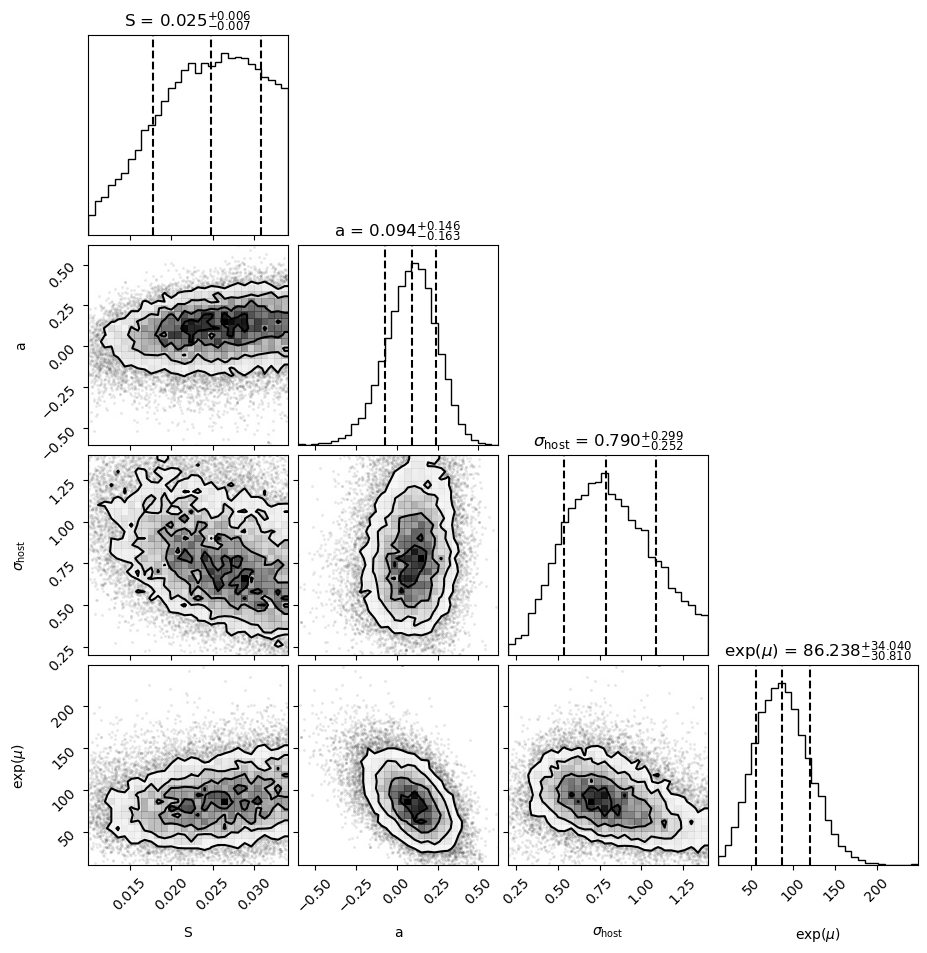

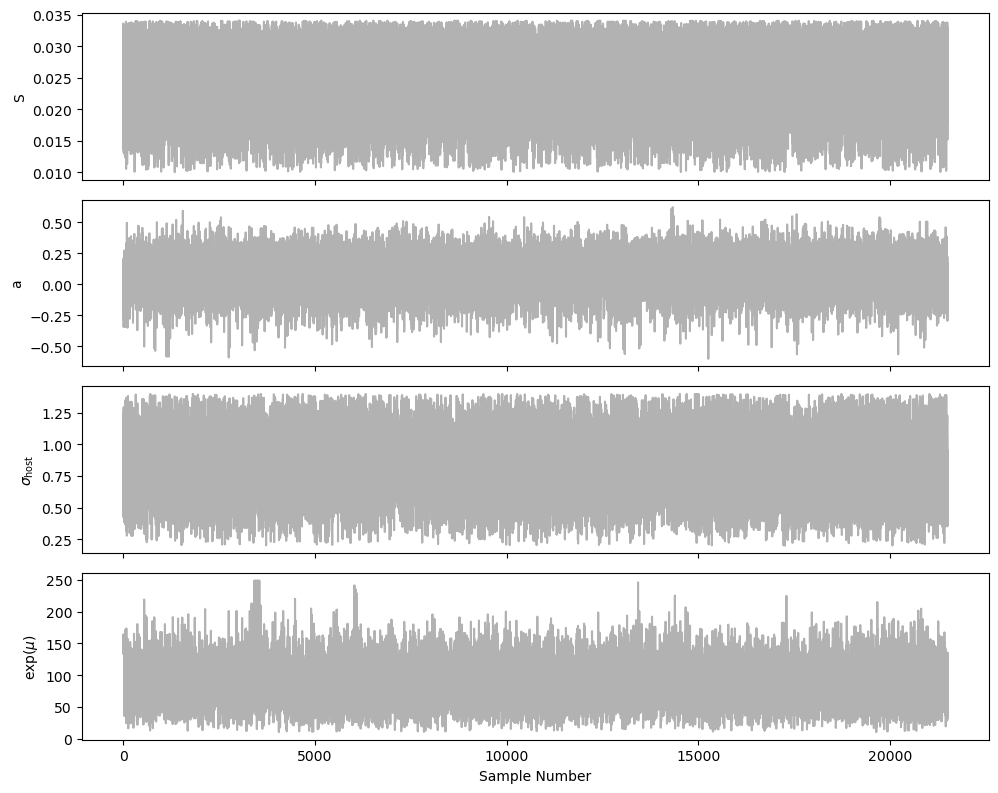

In [58]:
# param_names = ['S', r'$H_0 \Omega_b f_{\rm diff}$', 'a', r'$\sigma_{\rm host}$', r'$\exp(\mu)$']
param_names = ['S', 'a', r'$\sigma_{\rm host}$', r'$\exp(\mu)$']
samples=np.load('./posterior/mcmc_linear.npy')
mcmc_plot_results(samples, param_names,
                  savetitle='./plot/MCMC_linear'
                  )